



# 서울시 교통 혼잡 스트레스 종합 점수 (연도별)

| 출처 | 점수 | 설명 |
|------|------|------|
| `eda_commute_stress.ipynb` | 출퇴근 스트레스 점수 | 이동인구·시간·총이동시간 기반 |
| `교통_대중교통점수.ipynb` | 대중교통 혼잡도 점수 | 승·하차 강도 + 방향 불균형 |
| `parking_population_complaint_analysis.ipynb` | 주차 문제 점수 | 주차장확보율 기반 |
| `parking_population_complaint_analysis.ipynb` | 민원 문제 점수 | 인구 1만 명당 교통 민원 |

**교통_혼잡 스트레스 점수** = 4개 점수를 전체 연도 기준으로 0~100 정규화 후 단순 평균  
→ 연도 간 동일 기준으로 비교 가능 (75행 = 25구 × 3년)

In [16]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

GU_CODE = {
    '종로구':11010, '중구':11020,   '용산구':11030,  '성동구':11040,  '광진구':11050,
    '동대문구':11060,'중랑구':11070, '성북구':11080,  '강북구':11090,  '도봉구':11100,
    '노원구':11110, '은평구':11120, '서대문구':11130,'마포구':11140, '양천구':11150,
    '강서구':11160, '구로구':11170, '금천구':11180, '영등포구':11190,'동작구':11200,
    '관악구':11210, '서초구':11220, '강남구':11230,  '송파구':11240,  '강동구':11250,
}
GU_NAME_MAP = {v: k for k, v in GU_CODE.items()}

COMMUTE          = Path(r'C:/Users/sun94/Downloads/commute_stress_파이프라인/commute_stress_파이프라인/annual_avg_output/monthly_scores_문헌기반_서울_renorm.csv')
TRANSIT          = Path('bus_subway/gu_transport_stress_score_all_years.csv')
PARKING_QUARTERLY= Path('complain/data/outputs/quarterly_parking_complaint_scores.csv')

for label, p in [('출퇴근', COMMUTE), ('대중교통', TRANSIT), ('주차민원(분기)', PARKING_QUARTERLY)]:
    print(f'[{"OK" if p.exists() else "NOT FOUND"}] {label}: {p}')

[OK] 출퇴근: C:\Users\sun94\Downloads\commute_stress_파이프라인\commute_stress_파이프라인\annual_avg_output\monthly_scores_문헌기반_서울_renorm.csv
[OK] 대중교통: bus_subway\gu_transport_stress_score_all_years.csv
[OK] 주차민원(분기): complain\data\outputs\quarterly_parking_complaint_scores.csv


---
## 1. 데이터 로드 및 자치구별 집계

In [17]:
# ── 출퇴근 스트레스: 연도 × 자치구 평균 ───────────────────────
commute_raw = pd.read_csv(COMMUTE, encoding='utf-8-sig')
commute_raw = commute_raw[commute_raw['자치구코드'].isin(GU_CODE.values())].copy()
commute_raw['자치구명'] = commute_raw['자치구코드'].map(GU_NAME_MAP)

commute_gu = (
    commute_raw
    .groupby(['연도','자치구코드','자치구명'])['출퇴근스트레스점수']
    .mean().round(2).reset_index()
    .rename(columns={'연도':'year','출퇴근스트레스점수':'출퇴근_스트레스점수'})
)
print('출퇴근:', commute_gu.shape, '  연도:', sorted(commute_gu['year'].unique()))

# ── 대중교통 혼잡도: 연도 × 자치구 ────────────────────────────
transit_raw = pd.read_csv(TRANSIT, encoding='utf-8-sig')
transit_gu  = (
    transit_raw[['gu_name','year','transport_stress_score']]
    .rename(columns={'gu_name':'자치구명','transport_stress_score':'대중교통_혼잡도점수'})
)
print('대중교통:', transit_gu.shape, '  연도:', sorted(transit_gu['year'].unique()))

# ── 주차·민원: 분기별 → 연도 평균 ────────────────────────────
parking_q = pd.read_csv(PARKING_QUARTERLY, encoding='utf-8-sig')
parking_gu = (
    parking_q
    .groupby(['year','gu_name'])[['parking_score_100','complaint_score_100']]
    .mean().round(2).reset_index()
    .rename(columns={'gu_name':'자치구명',
                     'parking_score_100':'주차_문제점수',
                     'complaint_score_100':'민원_문제점수'})
)
print('주차민원:', parking_gu.shape, '  연도:', sorted(parking_gu['year'].unique()))

display(commute_gu.head(3))
display(transit_gu.head(3))
display(parking_gu.head(3))

출퇴근: (75, 4)   연도: [np.int64(2022), np.int64(2023), np.int64(2024)]
대중교통: (75, 3)   연도: [np.int64(2022), np.int64(2023), np.int64(2024)]
주차민원: (75, 4)   연도: [np.int64(2022), np.int64(2023), np.int64(2024)]


,year,자치구코드,자치구명,출퇴근_스트레스점수
0,2022,11010,종로구,39.79
1,2022,11020,중구,37.41
2,2022,11030,용산구,24.49


,자치구명,year,대중교통_혼잡도점수
0,종로구,2022,93.3
1,마포구,2022,88.0
2,중구,2022,85.3


,year,자치구명,주차_문제점수,민원_문제점수
0,2022,강남구,26.29,61.41
1,2022,강동구,64.36,17.86
2,2022,강북구,72.41,10.00


---
## 2. 병합 및 교통_혼잡 스트레스 점수 산출

In [18]:
# ── 연도 기준 병합 (year × 자치구명) ──────────────────────────
df = (
    commute_gu
    .merge(transit_gu,  on=['year','자치구명'], how='outer')
    .merge(parking_gu,  on=['year','자치구명'], how='outer')
)
df['자치구코드'] = df['자치구명'].map(GU_CODE)
df = df.sort_values(['year','자치구코드']).reset_index(drop=True)

SCORE_COLS = ['출퇴근_스트레스점수','대중교통_혼잡도점수','주차_문제점수','민원_문제점수']

print('shape:', df.shape, '  결측:')
print(df[SCORE_COLS].isnull().sum().to_dict())

# ── 전체 연도 기준 0~100 정규화 후 단순 평균 ─────────────────
# (연도 간 동일 스케일로 비교 가능)
for col in SCORE_COLS:
    lo, hi = df[col].min(), df[col].max()
    df[f'{col}_norm'] = ((df[col] - lo) / (hi - lo) * 100).round(2)

norm_cols = [f'{c}_norm' for c in SCORE_COLS]
df['교통_혼잡스트레스점수'] = df[norm_cols].mean(axis=1).round(2)

# ── 최종 컬럼 정리 ───────────────────────────────────────────
final = df[['year','자치구코드','자치구명'] + SCORE_COLS + ['교통_혼잡스트레스점수']].copy()
final = final.rename(columns={'year':'연도'})

print()
print('=== 최종 점수표 (연도별, 교통_혼잡스트레스점수 내림차순) ===')
display(final.sort_values(['연도','교통_혼잡스트레스점수'], ascending=[True,False]))

shape: (75, 7)   결측:
{'출퇴근_스트레스점수': 0, '대중교통_혼잡도점수': 0, '주차_문제점수': 0, '민원_문제점수': 0}

=== 최종 점수표 (연도별, 교통_혼잡스트레스점수 내림차순) ===


,연도,자치구코드,자치구명,출퇴근_스트레스점수,대중교통_혼잡도점수,주차_문제점수,민원_문제점수,교통_혼잡스트레스점수
22,2022,11230,강남구,70.27,68.0,26.29,61.41,62.74
13,2022,11140,마포구,32.11,88.0,33.77,66.83,56.70
1,2022,11020,중구,37.41,85.3,10.00,85.58,56.56
21,2022,11220,서초구,46.44,77.3,16.30,72.80,55.94
2,2022,11030,용산구,24.49,66.7,51.37,74.59,55.09
...,...,...,...,...,...,...,...,...
57,2024,11080,성북구,25.13,33.3,73.71,12.39,32.96
55,2024,11060,동대문구,22.89,42.7,48.91,29.59,32.44
64,2024,11150,양천구,15.92,9.3,90.00,19.58,29.28
59,2024,11100,도봉구,13.27,28.0,79.50,12.34,28.20


---
## 3. 시각화

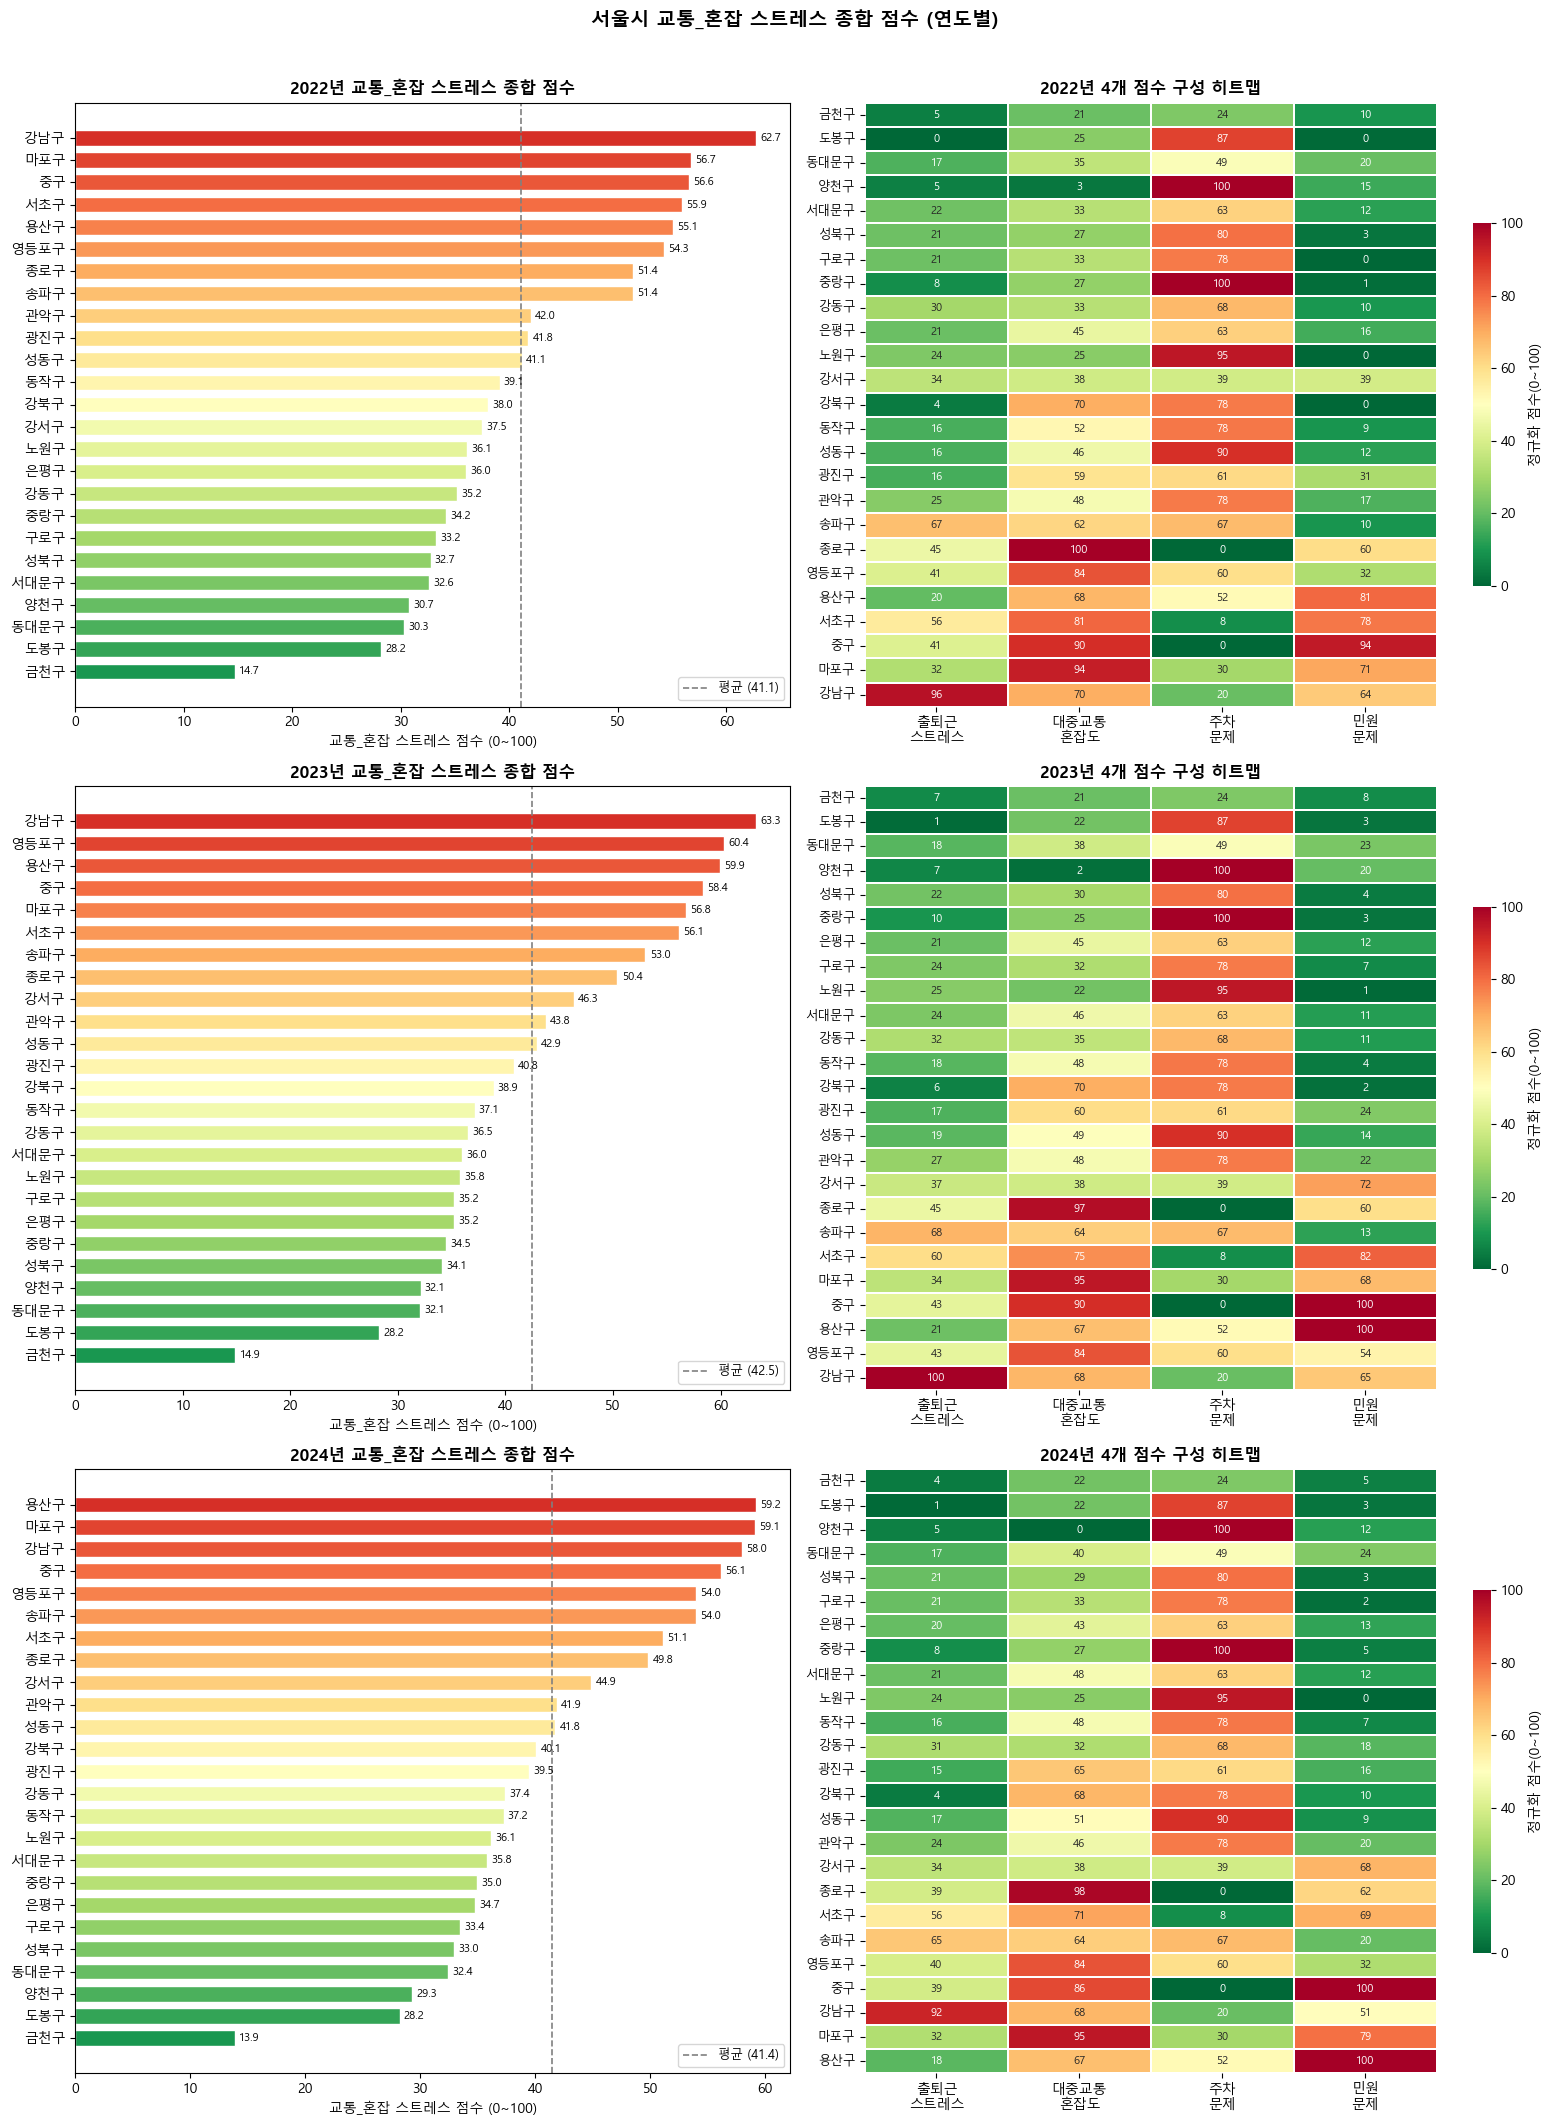

In [19]:
years = sorted(final['연도'].unique())
fig, axes = plt.subplots(len(years), 2, figsize=(16, 7 * len(years)))

for row_idx, yr in enumerate(years):
    yr_df = final[final['연도'] == yr].sort_values('교통_혼잡스트레스점수', ascending=True)

    # ① 연도별 최종 점수 가로 막대
    ax_bar = axes[row_idx, 0]
    colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(yr_df)))
    bars = ax_bar.barh(yr_df['자치구명'], yr_df['교통_혼잡스트레스점수'],
                       color=colors, edgecolor='white', height=0.7)
    ax_bar.bar_label(bars, fmt='%.1f', padding=3, fontsize=8)
    ax_bar.axvline(yr_df['교통_혼잡스트레스점수'].mean(), color='gray',
                   linestyle='--', linewidth=1.2,
                   label=f'평균 ({yr_df["교통_혼잡스트레스점수"].mean():.1f})')
    ax_bar.set_xlabel('교통_혼잡 스트레스 점수 (0~100)')
    ax_bar.set_title(f'{yr}년 교통_혼잡 스트레스 종합 점수', fontweight='bold')
    ax_bar.legend(fontsize=9)

    # ② 연도별 4개 점수 히트맵
    ax_hm = axes[row_idx, 1]
    hm_data = yr_df.set_index('자치구명')[SCORE_COLS].copy()
    # 전체 연도 스케일로 이미 정규화된 norm_cols 사용
    hm_norm = df[df['year'] == yr].set_index('자치구명')[[f'{c}_norm' for c in SCORE_COLS]]
    hm_norm = hm_norm.loc[yr_df['자치구명']]
    hm_norm.columns = ['출퇴근\n스트레스','대중교통\n혼잡도','주차\n문제','민원\n문제']
    sns.heatmap(hm_norm, ax=ax_hm, cmap='RdYlGn_r',
                annot=True, fmt='.0f', annot_kws={'size':8},
                linewidths=0.3, cbar_kws={'label':'정규화 점수(0~100)','shrink':0.6},
                vmin=0, vmax=100)
    ax_hm.set_title(f'{yr}년 4개 점수 구성 히트맵', fontweight='bold')
    ax_hm.set_ylabel('')
    ax_hm.tick_params(axis='y', labelsize=9)

plt.suptitle('서울시 교통_혼잡 스트레스 종합 점수 (연도별)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 4. 저장

In [ ]:
# ── 통합 CSV 저장 ────────────────────────────────────────────
out_all = Path('교통_혼잡_스트레스_종합점수.csv')
final.sort_values(['연도','교통_혼잡스트레스점수'], ascending=[True,False]).to_csv(
    out_all, index=False, encoding='utf-8-sig')
print('저장 완료 (전체):', out_all.resolve())

# ── 연도별 CSV 저장 ───────────────────────────────────────────
for yr in sorted(final['연도'].unique()):
    out_yr = Path(f'교통_혼잡_스트레스_종합점수_{yr}.csv')
    (final[final['연도'] == yr]
     .sort_values('교통_혼잡스트레스점수', ascending=False)
     .to_csv(out_yr, index=False, encoding='utf-8-sig'))
    print(f'저장 완료 ({yr}):', out_yr.name)

# ── 연도별 미리보기 ───────────────────────────────────────────
for yr in sorted(final['연도'].unique()):
    print(f'\n=== {yr}년 ===')
    display(final[final['연도']==yr]
            .sort_values('교통_혼잡스트레스점수', ascending=False)
            .reset_index(drop=True))

저장 완료 (전체): C:\8ssible-Healing-Seoul-Analysis\KM\traffic\교통_혼잡_스트레스_종합점수.csv
저장 완료 (2022): 교통_혼잡_스트레스_종합점수_2022.csv
저장 완료 (2023): 교통_혼잡_스트레스_종합점수_2023.csv
저장 완료 (2024): 교통_혼잡_스트레스_종합점수_2024.csv

=== 2022년 ===


,연도,자치구코드,자치구명,출퇴근_스트레스점수,대중교통_혼잡도점수,주차_문제점수,민원_문제점수,교통_혼잡스트레스점수
0,2022,11230,강남구,70.27,68.0,26.29,61.41,62.74
1,2022,11140,마포구,32.11,88.0,33.77,66.83,56.70
2,2022,11020,중구,37.41,85.3,10.00,85.58,56.56
3,2022,11220,서초구,46.44,77.3,16.30,72.80,55.94
4,2022,11030,용산구,24.49,66.7,51.37,74.59,55.09
5,2022,11190,영등포구,37.16,80.0,58.06,35.57,54.27
6,2022,11010,종로구,39.79,93.3,10.00,58.33,51.42
7,2022,11240,송파구,52.45,61.3,63.85,17.74,51.36
8,2022,11210,관악구,27.92,49.3,72.37,23.69,42.00
9,2022,11050,광진구,22.34,58.7,59.05,34.78,41.76



=== 2023년 ===


,연도,자치구코드,자치구명,출퇴근_스트레스점수,대중교통_혼잡도점수,주차_문제점수,민원_문제점수,교통_혼잡스트레스점수
0,2023,11230,강남구,72.37,66.7,26.29,61.65,63.31
1,2023,11190,영등포구,38.65,80.0,58.06,53.07,60.36
2,2023,11030,용산구,25.48,65.3,51.37,90.00,59.90
3,2023,11020,중구,38.50,85.3,10.00,90.00,58.40
4,2023,11140,마포구,33.38,89.3,33.77,64.04,56.75
5,2023,11220,서초구,48.81,72.0,16.30,75.33,56.15
6,2023,11240,송파구,53.56,62.7,63.85,20.22,53.01
7,2023,11010,종로구,39.52,90.7,10.00,57.94,50.41
8,2023,11160,강서구,34.77,41.3,40.83,67.50,46.34
9,2023,11210,관악구,29.18,49.3,72.37,27.60,43.76



=== 2024년 ===


,연도,자치구코드,자치구명,출퇴근_스트레스점수,대중교통_혼잡도점수,주차_문제점수,민원_문제점수,교통_혼잡스트레스점수
0,2024,11030,용산구,23.83,65.3,51.37,90.00,59.21
1,2024,11140,마포구,31.96,89.3,33.77,73.47,59.10
2,2024,11230,강남구,67.86,66.7,26.29,50.55,57.95
3,2024,11020,중구,35.92,81.3,10.00,90.00,56.12
4,2024,11190,영등포구,36.53,80.0,58.06,35.49,53.98
5,2024,11240,송파구,51.54,62.7,63.85,26.00,53.97
6,2024,11220,서초구,46.12,69.3,16.30,65.45,51.13
7,2024,11010,종로구,36.06,92.0,10.00,59.49,49.83
8,2024,11160,강서구,33.37,41.3,40.83,64.71,44.88
9,2024,11210,관악구,26.85,48.0,72.37,26.00,41.89


: 